# Connotation Frame Analysis

We apply the **Riveter** framework ([Antoniak et al., 2023](http://maartensap.com/pdfs/antoniak2023riveter.pdf)) built on the Connotation Frames lexicon of [Sap et al. (2017)](https://arxiv.org/abs/1702.01151) to measure power, agency, and sentiment dynamics in our opium literature corpus.

First we load the lexicons:

In [1]:
import pandas as pd
import numpy as np
import spacy

nlp = spacy.load("en_core_web_sm")

/Users/ngocdoan/opt/anaconda3/envs/history39/lib/python3.9/site-packages/spacy/cli/info.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/ngocdoan/opt/anaconda3/envs/history39/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Sentiment Lexicon (Rashkin et al. 2016)
cf_df = pd.read_csv('../../frameworks/connotation_frame/rashkin-lexicon/full_frame_info.txt', sep='\t')
sentiment_dict = cf_df.set_index('verb')[['writer_perspective(a)', 'writer_perspective(t)']].to_dict('index')
list(sentiment_dict.items())[:10]

[('have',
  {'writer_perspective(a)': 0.333333333333,
   'writer_perspective(t)': 0.366666666667}),
 ('say',
  {'writer_perspective(a)': 0.166666666667, 'writer_perspective(t)': 0.0}),
 ('make',
  {'writer_perspective(a)': 0.1, 'writer_perspective(t)': -0.0666666666667}),
 ('take', {'writer_perspective(a)': 0.6, 'writer_perspective(t)': 0.5}),
 ('go',
  {'writer_perspective(a)': 0.133333333333,
   'writer_perspective(t)': 0.0666666666667}),
 ('come',
  {'writer_perspective(a)': 0.3, 'writer_perspective(t)': 0.0666666666667}),
 ('get',
  {'writer_perspective(a)': 0.333333333333, 'writer_perspective(t)': 0.2}),
 ('know',
  {'writer_perspective(a)': 0.5, 'writer_perspective(t)': 0.366666666667}),
 ('give',
  {'writer_perspective(a)': 0.4, 'writer_perspective(t)': 0.233333333333}),
 ('include',
  {'writer_perspective(a)': 0.266666666667,
   'writer_perspective(t)': 0.433333333333})]

In [3]:
# Agency and Power Lexicon (Sap et al. 2017)
ap_df = pd.read_csv('../../frameworks/connotation_frame/sap-lexicon/agency_power.csv')
ap_df_combined = ap_df.groupby('verb', as_index=False).agg(lambda x: x.dropna().iloc[0] if not x.dropna().empty else np.nan) # combine dup rows
ap_dict = ap_df_combined.set_index('verb').to_dict('index')
list(ap_dict.items())[:10]

[('abandon', {'agency': 'agency_pos', 'power': 'power_agent'}),
 ('abolish', {'agency': 'agency_pos', 'power': 'power_agent'}),
 ('absorb', {'agency': 'agency_pos', 'power': 'power_agent'}),
 ('abuse', {'agency': 'agency_pos', 'power': 'power_agent'}),
 ('accelerate', {'agency': 'agency_pos', 'power': 'power_agent'}),
 ('accept', {'agency': 'agency_neg', 'power': 'power_agent'}),
 ('access', {'agency': 'agency_equal', 'power': 'power_agent'}),
 ('accommodate', {'agency': 'agency_pos', 'power': 'power_equal'}),
 ('accompany', {'agency': 'agency_equal', 'power': 'power_theme'}),
 ('accomplish', {'agency': 'agency_pos', 'power': 'power_equal'})]

Score mapping logic according to lexicon labels:

In [5]:
def get_agency_score(agency_label):
    if not isinstance(agency_label, str): return np.nan
    if agency_label == 'agency_pos': return 1.0
    if agency_label == 'agency_neg': return -1.0
    if agency_label == 'agency_equal': return 0.0
    return np.nan

def get_power_score(power_label, role):
    if not isinstance(power_label, str): return np.nan
    
    # If the verb empowers the Agent (Subject)
    if power_label == 'power_agent':
        return 1.0 if role == 'agent' else -1.0
        
    # If the verb empowers the Theme (Object)
    elif power_label == 'power_theme':
        return -1.0 if role == 'agent' else 1.0
        
    # If power is equal/neutral
    elif power_label == 'power_equal':
        return 0.0
        
    return np.nan

In [6]:
# reusing gendered vocabs from gender extraction
MALE_VOCAB = {
    'he', 'him', 'his', 'man', 'boy', 'gentleman',
    'father', 'brother', 'husband', 'uncle',
    'son', 'master', 'sir', 'lord', 'clergyman',
    'mr', 'mister', 'colonel', 'major', 'captain'
}

FEMALE_VOCAB = {
    'she', 'her', 'hers', 'woman', 'girl', 'lady',
    'mother', 'sister', 'wife', 'aunt',
    'daughter', 'mistress', 'widow', 'governess', 
    'nurse', 'mrs', 'miss', 'madam', 'madame'
}

Connotation scoring logic:
1. Find the Match: Find a target (gendered) word (e.g., "she").
2. Find the Verb: Use a dependency parser to find the verb acting on "she" (e.g., "yield").
3. Determine the Role: Is "she" the Subject (Agent) or Object (Theme) of "yield"?
4. Look up the Score: If "she" is the Subject, look up the agency score and power (agent) score for "yield" in the Sap et al. lexicon.
Example: "yield" has an Agency score of -1 and a Power score of -1.
5. Average it Out: If "she" appears 100 times in the dataset, sum up all those 1, 0, and -1 scores and divide by 100.

In [7]:
def calculate_connotations(row):
    text = str(row['Snippet'])
    target_gender = row['Assigned_Gender']
    
    # Skip if not Male or Female
    if target_gender not in ['Male', 'Female']:
        return pd.Series({'Agency': np.nan, 'Power': np.nan, 'Sentiment': np.nan})
        
    doc = nlp(text)
    vocab = FEMALE_VOCAB if target_gender == 'Female' else MALE_VOCAB
    
    agency_scores = []
    power_scores = []
    sentiment_scores = []
    
    for token in doc:
        # Check if the word belongs to the target gender
        if token.text.lower() in vocab:
            head = token.head
            
            # Check if the word is attached to a verb
            if head.pos_ == 'VERB':
                verb = head.lemma_.lower()
                
                # Determine role based on dependency
                role = None
                if token.dep_ == 'nsubj':
                    role = 'agent'
                elif token.dep_ in ['nsubjpass', 'dobj', 'pobj', 'dative']:
                    role = 'theme'
                
                if role == 'agent':
                    # 1. Sentiment Lookup
                    if verb in sentiment_dict:
                        sentiment_scores.append(sentiment_dict[verb]['writer_perspective(a)'])
                        
                    # 2. Agency & Power Lookup
                    if verb in ap_dict:
                        agency_label = ap_dict[verb].get('agency')
                        power_label = ap_dict[verb].get('power')
                        
                        agency_scores.append(get_agency_score(agency_label))
                        power_scores.append(get_power_score(power_label, role='agent'))

                elif role == 'theme':
                    # 1. Sentiment Lookup
                    if verb in sentiment_dict:
                        sentiment_scores.append(sentiment_dict[verb]['writer_perspective(t)'])
                        
                    # 2. Power Lookup (Objects/Passive subjects rarely get agency in this framework)
                    if verb in ap_dict:
                        power_label = ap_dict[verb].get('power')
                        power_scores.append(get_power_score(power_label, role='theme'))

    # Drop NaNs from lists before averaging
    agency_scores = [s for s in agency_scores if pd.notna(s)]
    power_scores = [s for s in power_scores if pd.notna(s)]
    sentiment_scores = [s for s in sentiment_scores if pd.notna(s)]

    # Return the averages for this snippet
    return pd.Series({
        'Agency': np.mean(agency_scores) if agency_scores else np.nan,
        'Power': np.mean(power_scores) if power_scores else np.nan,
        'Sentiment': np.mean(sentiment_scores) if sentiment_scores else np.nan
    })


In [8]:
df_all = pd.read_csv('../../data/snippets/total_snippets_with_gender.csv')

# Keep only snippets where we are confident about the gender
# 'Male' and 'Female' are directly resolved; we exclude Unknown / Dialogue rows
df = df_all[df_all['Assigned_Gender'].isin(['Male', 'Female'])].copy()
df = df.reset_index(drop=True)

print(f"Total gendered snippets: {len(df)}")
print(df['Assigned_Gender'].value_counts())

Total gendered snippets: 3697
Assigned_Gender
Male      2713
Female     984
Name: count, dtype: int64


In [9]:
from tqdm import tqdm
tqdm.pandas()
df[['Agency', 'Power', 'Sentiment']] = df.progress_apply(calculate_connotations, axis=1)

100%|██████████| 3697/3697 [02:35<00:00, 23.76it/s]


In [10]:
# Filter out snippets that didn't have any CF verbs
analysis_df = df.dropna(subset=['Agency', 'Power', 'Sentiment'], how='all')

# Print the final averages
print("\n=== CONNOTATION FRAME AVERAGES BY GENDER ===")
print(analysis_df.groupby('Assigned_Gender')[['Agency', 'Power', 'Sentiment']].mean())


=== CONNOTATION FRAME AVERAGES BY GENDER ===
                   Agency     Power  Sentiment
Assigned_Gender                               
Female           0.416227  0.112297   0.276373
Male             0.486742  0.169289   0.264776


The numbers look close at first glance (e.g., 0.41 vs 0.48), but in Connotation Frames, a gap of 0.05 to 0.07 is actually quite substantial. Because scores are bounded between -1 and 1—and are heavily diluted by hundreds of neutral verbs (scored 0)—aggregate averages rarely look like 0.9 vs -0.9. Bias in literature is subtle but systemic.

Let's check the statistical significance of this gap:

=== STATISTICAL SIGNIFICANCE (T-TESTS) ===
Agency: p-value = 0.0008 -> *** SIGNIFICANT ***
Power: p-value = 0.0056 -> *** SIGNIFICANT ***
Sentiment: p-value = 0.0113 -> *** SIGNIFICANT ***


/var/folders/2j/w898mtss6bncgwx8ldvsq6yr0000gn/T/ipykernel_2279/3985600041.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/2j/w898mtss6bncgwx8ldvsq6yr0000gn/T/ipykernel_2279/3985600041.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/2j/w898mtss6bncgwx8ldvsq6yr0000gn/T/ipykernel_2279/3985600041.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


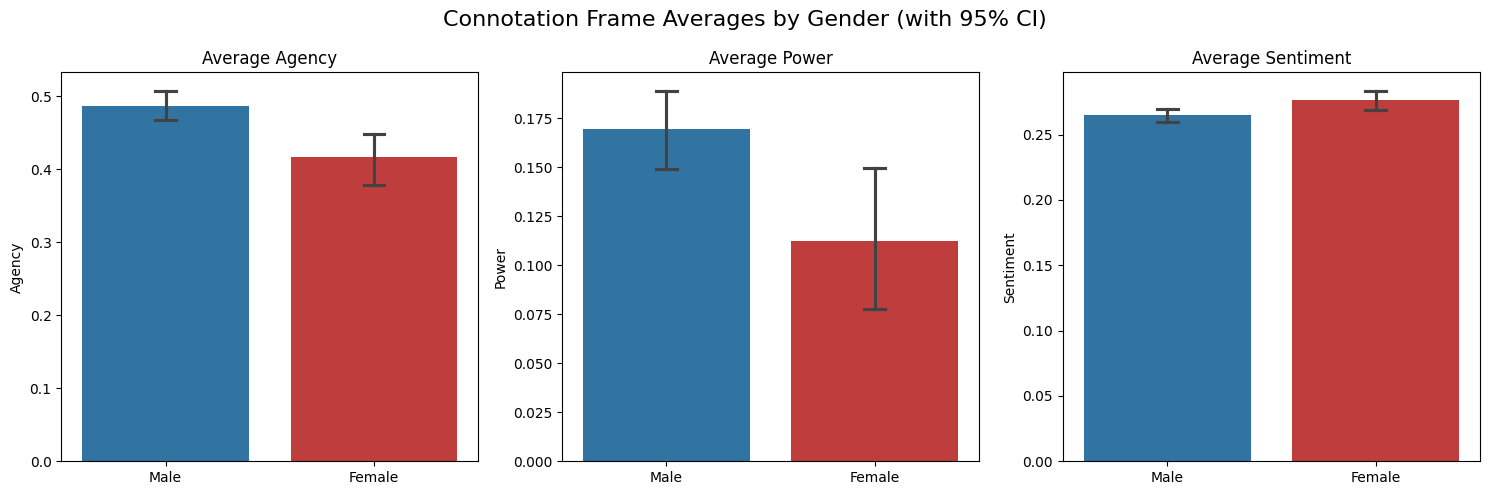

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# 1. Separate the data
female_data = analysis_df[analysis_df['Assigned_Gender'] == 'Female']
male_data = analysis_df[analysis_df['Assigned_Gender'] == 'Male']

print("=== STATISTICAL SIGNIFICANCE (T-TESTS) ===")
for metric in ['Agency', 'Power', 'Sentiment']:
    # Drop NaNs for the specific metric
    f_scores = female_data[metric].dropna()
    m_scores = male_data[metric].dropna()
    
    t_stat, p_val = ttest_ind(f_scores, m_scores, equal_var=False)
    
    # Check if the difference is significant
    sig = "*** SIGNIFICANT ***" if p_val < 0.05 else "Not Significant"
    print(f"{metric}: p-value = {p_val:.4f} -> {sig}")

# 2. Plotting with Confidence Intervals
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Connotation Frame Averages by Gender (with 95% CI)', fontsize=16)

metrics = ['Agency', 'Power', 'Sentiment']
colors = {'Male': '#1f77b4', 'Female': '#d62728'}

for i, metric in enumerate(metrics):
    sns.barplot(
        data=analysis_df, 
        x='Assigned_Gender', 
        y=metric, 
        palette=colors, 
        ax=axes[i], 
        capsize=0.1
    )
    axes[i].set_title(f'Average {metric}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig('../../data/snippets/cf_metrics_plot.png', dpi=150)
plt.show()

What verbs are driving these scores for each gender?

In [17]:
from collections import Counter

# Re-initialize spaCy and lexicons if needed (assuming ap_dict is still in memory)
# We will do a quick pass just to collect the verbs this time.

def collect_cf_verbs(row):
    text = str(row['Snippet'])
    target_gender = row['Assigned_Gender']
    
    if target_gender not in ['Male', 'Female']: return []
        
    doc = nlp(text)
    vocab = FEMALE_VOCAB if target_gender == 'Female' else MALE_VOCAB
    verbs_used = []
    
    for token in doc:
        if token.text.lower() in vocab:
            head = token.head
            if head.pos_ == 'VERB':
                verb = head.lemma_.lower()
                if verb in ap_dict: # If it's a CF-tracked verb
                    
                    # Subject verbs (Agent)
                    if token.dep_ in ['nsubj', 'nsubjpass']:
                        power = get_power_score(ap_dict[verb].get('power'), 'agent')
                        if pd.notna(power):
                            verbs_used.append((verb, power, 'Subject'))
                            
                    # Object verbs (Theme)
                    elif token.dep_ in ['dobj', 'pobj', 'dative']:
                        power = get_power_score(ap_dict[verb].get('power'), 'theme')
                        if pd.notna(power):
                            verbs_used.append((verb, power, 'Object'))
                            
    return verbs_used

print("Extracting verbs...")
# Apply verb extractor
all_verbs = df.apply(lambda row: (row['Assigned_Gender'], collect_cf_verbs(row)), axis=1)

# Separate and count
male_high_power = Counter()
male_low_power = Counter()
female_high_power = Counter()
female_low_power = Counter()

for gender, verbs in all_verbs:
    for verb, power, role in verbs:
        if gender == 'Male':
            if power > 0: male_high_power[verb] += 1
            elif power < 0: male_low_power[verb] += 1
        elif gender == 'Female':
            if power > 0: female_high_power[verb] += 1
            elif power < 0: female_low_power[verb] += 1

Extracting verbs...


In [18]:
print("\n=== TOP VERBS DRIVING MALE POWER (>0) ===")
print([v for v, c in male_high_power.most_common(10)])

print("\n=== TOP VERBS DRIVING FEMALE POWER DOWN (<0) ===")
print([v for v, c in female_low_power.most_common(10)])

print("\n=== TOP VERBS DRIVING FEMALE POWER (>0) ===")
print([v for v, c in female_high_power.most_common(10)])


=== TOP VERBS DRIVING MALE POWER (>0) ===
['know', 'do', 'give', 'make', 'get', 'turn', 'leave', 'write', 'keep', 'return']

=== TOP VERBS DRIVING FEMALE POWER DOWN (<0) ===
['give', 'leave', 'become', 'hear', 'ask', 'want', 'bring', 'lose', 'suffer', 'call']

=== TOP VERBS DRIVING FEMALE POWER (>0) ===
['know', 'do', 'make', 'give', 'get', 'turn', 'put', 'leave', 'hold', 'keep']


Maybe we can also look into agency and sentiment? And maybe we can also extract the context (like the sentence that has the verb) for better inspection?

### Extracting Contexts for Inspection

To better understand the scores, let's build a function to pull out the exact sentences where a specific verb is applied to a gender.

In [30]:
from IPython.display import display, HTML
import sys
sys.path.append('../../code')
from utils.constants import KEYWORDS

def show_contexts(target_verb, target_gender, target_role='agent', num_samples=5):
    count = 0
    vocab = FEMALE_VOCAB if target_gender == 'Female' else MALE_VOCAB
    
    html = f"<h3 style='margin-bottom: 5px;'>Contexts for <b>{target_gender}</b> as <b>{target_role}</b> of <i>'{target_verb}'</i></h3>"
    html += "<table style='text-align: left; width: 100%; border-collapse: collapse;'>"
    html += "<tr style='border-bottom: 2px solid black;'><th style='padding: 8px;'>Pronoun</th><th style='padding: 8px;'>Context Snippet</th></tr>"
    
    # We iterate over snippets assigned to the target gender
    for text in df[df['Assigned_Gender'] == target_gender]['Snippet'].dropna():
        doc = nlp(text)
        for token in doc:
            if token.text.lower() in vocab:
                head = token.head
                if head.pos_ == 'VERB' and head.lemma_.lower() == target_verb:
                    
                    role = None
                    if token.dep_ in ['nsubj', 'nsubjpass']: role = 'agent'
                    elif token.dep_ in ['dobj', 'pobj', 'dative']: role = 'theme'
                        
                    if role == target_role:
                        # Rebuild the string with HTML highlights
                        words = []
                        for t in doc:
                            # Check if the token is an opium keyword
                            is_keyword = t.text.lower() in KEYWORDS or t.lemma_.lower() in KEYWORDS
                            
                            if t == token:
                                words.append(f"<b style='color: blue;'>{t.text}</b>" + t.whitespace_)
                            elif t == head:
                                words.append(f"<b style='color: red;'>{t.text}</b>" + t.whitespace_)
                            elif is_keyword:
                                words.append(f"<b style='color: green; background-color: #e6ffe6; padding: 2px;'>{t.text}</b>" + t.whitespace_)
                            else:
                                words.append(t.text_with_ws)
                        highlighted_text = "".join(words)
                        
                        html += f"<tr style='border-bottom: 1px solid #ddd;'>"
                        html += f"<td style='padding: 8px; vertical-align: top; width: 10%;'><b>{token.text}</b></td>"
                        html += f"<td style='padding: 8px;'>{highlighted_text}</td>"
                        html += "</tr>"
                        
                        count += 1
                        if count >= num_samples:
                            break
        if count >= num_samples:
            break
            
    html += "</table>"
    if count == 0:
        html += "<p><i>No examples found.</i></p>"
        
    display(HTML(html))

# Example usage based on top power verbs
show_contexts('know', 'Male', 'agent')
show_contexts('make', 'Female', 'theme')


Pronoun,Context Snippet
he,"that?” he asked. “Why this,” I answered. “That I shall ill requite the very great honours Ruritania has done me if I depart from it leaving one of those Six alive--neither with the help of God, will I.” And Sapt shook my hand on that. CHAPTER 13 An Improvement on Jacob’s Ladder In the morning of the day after that on which I swore my oath against the Six, I gave certain orders, and then rested in greater contentment than I had known for some time. I was at work; and work, though it cannot cure love, is yet a narcotic to it; so that Sapt, who grew feverish, marvelled to see me sprawling in an armchair in the sunshine, listening to one of my friends who sang me amorous songs in a mellow voice and induced in me a pleasing melancholy. Thus was I engaged when young Rupert Hentzau, who feared neither man nor devil, and rode through the demesne--where every tree might hide a marksman, for all he knew--as though it had been the park at Strelsau, cantered up to where I lay, bowing with burlesque deference, and craving private speech with me in order to deliver a message"
he,"cheerfulness in his tone. “He’s gone very deep, sir,” said Mrs. Abel. “He went off gradual between three and four o’clock. Would you please to go and look at him? I thought it no harm to leave him. My man’s gone afield, and the little girl’s seeing to the kettles.” Bulstrode went up. At a glance he knew that Raffles was not in the sleep which brings revival, but in the sleep which streams deeper and deeper into the gulf of death. He looked round the room and saw a bottle with some brandy in it, and the almost empty opium phial. He put the phial out of sight, and carried the brandy-bottle down-stairs with him, locking it again in the wine-cooler. While breakfasting he considered whether he should ride to Middlemarch at once, or wait for Lydgate’s arrival. He decided to wait, and told Mrs. Abel that she might go about her work—he could watch in the bed-chamber. As he sat there and beheld the enemy of his peace going irrevocably into silence, he felt more at rest than he had done for many months. His conscience was soothed by the enfolding wing of secrecy, which seemed just then like"
his,"now I know what it means. Witty—but I can give him a night’s rest in spite of his teeth. He really wants sleep; and Lady Verinder’s medicine chest is at my disposal. Give him five-and-twenty minims of laudanum tonight, without his knowing it; and then call tomorrow morning. ‘Well, Mr. Blake, will you try a little medicine today? You will never sleep without it.’—‘There you are out, Mr. Candy: I have had an excellent night’s rest without it.’ Then, come down on him with the truth! ‘You have had something besides an excellent night’s rest; you had a dose of laudanum , sir, before you went to bed. What do you say to the art of medicine, now?’” Admiration of the ingenuity which had woven this smooth and finished texture out of the ravelled skein was naturally the first impression that I felt, on handing the manuscript back to Ezra Jennings. He modestly interrupted the first few words in which my sense of surprise expressed itself, by asking me if the conclusion which he had drawn from his notes was also the conclusion at which my own mind had arrived. “Do you believe as I believe,” he said, “that you were"
man,"whom you, personally, may at some time unwittingly, have been--I am aware that much must be omitted. I have no space for lengthy examinations of the many points but ill illuminated with which it is dotted. This incident at the docks is but one such point. Another is the singular vision which appeared to me whilst I lay in the cellar of the house near Windsor. It has since struck me that it possessed peculiarities akin to those of a hashish hallucination. Can it be that we were drugged on that occasion with Indian hemp? Cannabis indica is a treacherous narcotic , as every medical man knows full well; but Fu-Manchu's knowledge of the drug was far in adva

Pronoun,Context Snippet
her,"off went Mitaele on Musu to fetch Tauilo, Talolo's mother. So here was all the island in a bustle over Sina's foot. No doctor came, but he told us what to put on. When I went up at night to the little room, I found Tauilo there, and the whole plantation boxed into the place like little birds in a nest. They were sitting on the bed, they were sitting on the table, the floor was full of them, and the place as close as the engine-room of a steamer. In the middle lay Sina, about three parts asleep with opium ; two able-bodied work-boys were pulling at her arms, and whenever she closed her eyes calling her by name, and talking in her ear. I really didn't know what would become of the girl before morning. Whether or not she had been very ill before, this was the way to make her so, and when one of the work-boys woke her up again, I spoke to him very sharply, and told Tauilo she must put a stop to it. Now I suppose this was what put it into Tauilo's head to do what she did next. You remember Tauilo, and"
her,"going on in Salisbury--she must prove an alibi--then it would be known that she had been absent from home when her husband died. The imminence of the danger made her at last feel quiet and steady. She took up the lighted candle and went into the dairy--she unlocked the cupboard in the wall and took out the bottle of laudanum. Returning to the kitchen she emptied the contents of the bottle into the range and then threw the bottle itself also into the heart of the fire--she watched it as it slowly melted under the influence of the hot fire--the laudanum itself was also licked up by the hungry flames. That tell-tale and awful evidence of her guilt was at least removed. She forgot all about Susan having seen the liquid in the morning--she knew nothing about the evidence which would be brought to light at a coroner's inquest--about the facts which a doctor would be sure to give. Nothing but the bare reality remained prominently before her excited brain. Vincent was dead--she had killed him by an overdose of laudanum which she had given him in all innocence to make him sleep--but yet, yet in her heart of hearts, she"
her,"a rudely unresponsive dwarf. Below her the sea grunted with automatic fury and receded, like a pleased actor. Winds threw their weird applause against the blue and gray rocks. The calmer air underneath the tree was not unlike a distressed mind caught between the noises. Ethel Curn seated herself beneath the tree and read a paper-bound novel entitled, “The Fate of Eleanor Martin,” but the sea and the rocks interfered too effectively with Eleanor and her pretended life slid into the reality at the foot of the tree, while Ethel peered aggressively down at the waves. A whim winked its narcotic eye at her mind--the waves became fellow-workers and she was an audience critically examining their turns. “A little higher with that green somersault! Come on, old chicken, you can do a longer slide if you try!” her mind cried amiably. Lost in the syncopation of admiration her body swayed with the waves and her brown hair went adventuring. Then, like a jilted servant, her mood ran from her, brandishing its abashed haste over her body. Sorrow struck her face with a crazily gay second that extinguished her eyes. Her body improvised its lines into a wilted sexlessness that made her"


### Agency & Sentiment Verbs

Just like we did for Power, let's extract the verbs driving Agency and Sentiment.

In [20]:
from collections import Counter

def get_top_verbs(counter, n=10):
    return [(v, c) for v, c in counter.most_common(n)]

male_high_power = Counter()
male_low_power = Counter()
female_high_power = Counter()
female_low_power = Counter()

male_high_agency = Counter()
male_low_agency = Counter()
female_high_agency = Counter()
female_low_agency = Counter()

male_pos_sentiment = Counter()
male_neg_sentiment = Counter()
female_pos_sentiment = Counter()
female_neg_sentiment = Counter()

print("Extracting all verbs for Power, Agency & Sentiment...")
for idx, row in df.iterrows():
    text = str(row['Snippet'])
    target_gender = row['Assigned_Gender']
    if target_gender not in ['Male', 'Female']: continue
        
    doc = nlp(text)
    vocab = FEMALE_VOCAB if target_gender == 'Female' else MALE_VOCAB
    
    for token in doc:
        if token.text.lower() in vocab:
            head = token.head
            if head.pos_ == 'VERB':
                verb = head.lemma_.lower()
                role = None
                if token.dep_ in ['nsubj', 'nsubjpass']: role = 'agent'
                elif token.dep_ in ['dobj', 'pobj', 'dative']: role = 'theme'
                
                if role and verb in ap_dict:
                    # Power
                    power = get_power_score(ap_dict[verb].get('power'), role)
                    if pd.notna(power):
                        if power > 0:
                            if target_gender == 'Male': male_high_power[verb] += 1
                            else: female_high_power[verb] += 1
                        elif power < 0:
                            if target_gender == 'Male': male_low_power[verb] += 1
                            else: female_low_power[verb] += 1
                            
                    # Agency (Agency is only assigned to the Agent)
                    if role == 'agent':
                        agency = get_agency_score(ap_dict[verb].get('agency'))
                        if pd.notna(agency):
                            if agency > 0:
                                if target_gender == 'Male': male_high_agency[verb] += 1
                                else: female_high_agency[verb] += 1
                            elif agency < 0:
                                if target_gender == 'Male': male_low_agency[verb] += 1
                                else: female_low_agency[verb] += 1
                            
                if role and verb in sentiment_dict:
                    sent_key = 'writer_perspective(a)' if role == 'agent' else 'writer_perspective(t)'
                    sentiment = sentiment_dict[verb][sent_key]
                    if pd.notna(sentiment):
                        if sentiment > 0:
                            if target_gender == 'Male': male_pos_sentiment[verb] += 1
                            else: female_pos_sentiment[verb] += 1
                        elif sentiment < 0:
                            if target_gender == 'Male': male_neg_sentiment[verb] += 1
                            else: female_neg_sentiment[verb] += 1
print("Done!")


Extracting all verbs for Power, Agency & Sentiment...
Done!


### Visualizing Top Verbs
Now we can visualize these frequencies as a heatmap to see exactly how male and female characters are framed by these dimensions.

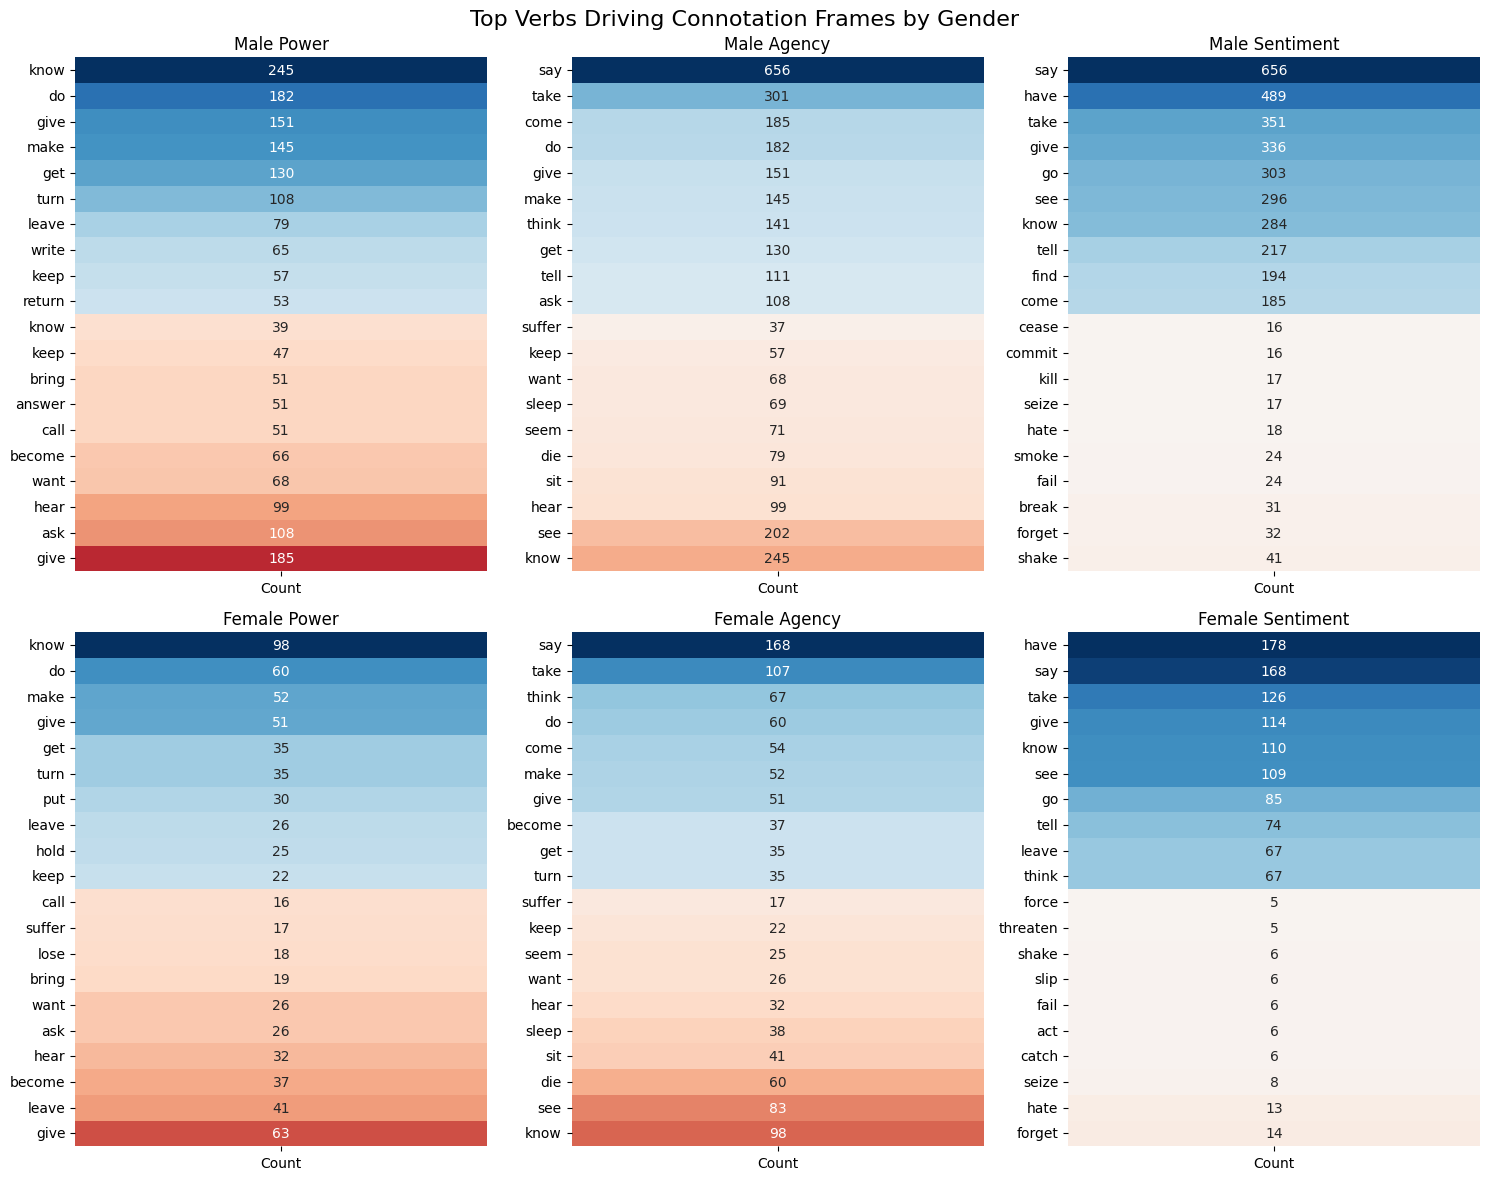

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_top_verbs(high_counter, low_counter, title, ax):
    # Combine top positive and top negative verbs
    top_pos = get_top_verbs(high_counter, 10)
    top_neg = get_top_verbs(low_counter, 10)
    
    # For heatmap, we want values. Positive counts are > 0, negative counts we'll make < 0 for visualization
    verbs = [v for v, c in top_pos] + [v for v, c in top_neg[::-1]]
    counts = [c for v, c in top_pos] + [-c for v, c in top_neg[::-1]]
    
    if not verbs:
        return
        
    df_plot = pd.DataFrame({'Count': counts}, index=verbs)
    
    # Custom divergent colormap
    sns.heatmap(df_plot, 
                annot=df_plot.abs(), # display absolute counts
                cmap='RdBu',
                center=0,
                cbar=False,
                fmt='d',
                ax=ax)
    ax.set_title(title)
    ax.set_ylabel('')

fig, axes = plt.subplots(2, 3, figsize=(15, 12))
fig.suptitle('Top Verbs Driving Connotation Frames by Gender', fontsize=16)

plot_top_verbs(male_high_power, male_low_power, 'Male Power', axes[0, 0])
plot_top_verbs(male_high_agency, male_low_agency, 'Male Agency', axes[0, 1])
plot_top_verbs(male_pos_sentiment, male_neg_sentiment, 'Male Sentiment', axes[0, 2])

plot_top_verbs(female_high_power, female_low_power, 'Female Power', axes[1, 0])
plot_top_verbs(female_high_agency, female_low_agency, 'Female Agency', axes[1, 1])
plot_top_verbs(female_pos_sentiment, female_neg_sentiment, 'Female Sentiment', axes[1, 2])

plt.tight_layout()
plt.savefig('../../data/snippets/cf_verbs_heatmap.png', dpi=150)
plt.show()

### Qualitative Spot-Checking
Let's look at a few examples where sentiment or agency differ.

In [22]:
# Let's look at some examples of high male agency and low female agency
show_contexts('know', 'Male', 'agent', num_samples=2)
show_contexts('make', 'Female', 'theme', num_samples=2)

show_contexts('give', 'Male', 'agent', num_samples=2)
show_contexts('leave', 'Female', 'theme', num_samples=2)


=== Contexts for Male as agent of 'know' ===
- "Thus was I engaged when young Rupert Hentzau, who feared neither man nor devil, and rode through the demesne--where every tree might hide a marksman, for all he knew--as though it had been the park at Strelsau, cantered up to where I lay, bowing with burlesque deference, and craving private speech with me in order to deliver a message"
- "At a glance he knew that Raffles was not in the sleep which brings revival, but in the sleep which streams deeper and deeper into the gulf of death."

=== Contexts for Female as theme of 'make' ===
- "“Can she be made to rap for us?”"
- "Whether or not she had been very ill before, this was the way to make her so, and when one of the work-boys woke her up again, I spoke to him very sharply, and told Tauilo she must put a stop to it."

=== Contexts for Male as agent of 'give' ===
- "He had taken the precaution of bringing opium in his pocket, and he gave minute directions to Bulstrode as to the doses, an